In [63]:
%matplotlib inline

from src.constants import PROCESSED_DATA_PATH, RAW_DATA_PATH

import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
import matplotlib.colors as mcolors
import umap
import umap.plot
import xarray as xr

from scipy.ndimage import gaussian_filter1d
from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.signal.windows import gaussian

import pynaviz as viz
from pynaviz import scope

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)
unit_id = "107b"

prj = nap.load_folder(PROCESSED_DATA_PATH.parent)
prj.view

📂 ucsf
├── 📂 external
│   └── 📂 107b
├── 📂 interim
│   └── 📂 107b
│       ├── 📂 umap_correlation
│       ├── 📂 umap_cosine
│       ├── 📂 umap_euclidean
│       ├── 📂 umap_mahalanobis
│       ├── 📂 umap_manhattan
│       ├── hd_burst_epochs.npz     |        IntervalSet
│       └── hd_pop_zrate.npz        |        Tsd
├── 📂 processed
│   ├── 📂 107b
│   │   ├── active_wake.npz         |        IntervalSet
│   │   ├── angle_openfield.npz     |        Tsd
│   │   ├── hd_spikes_openfield.npz         |        TsdFrame
│   │   ├── hd_spikes_total.npz     |        TsGroup
│   │   ├── hd_spikes_wake_filtered.npz     |        TsGroup
│   │   ├── manifold_wake.npz       |        TsdFrame
│   │   ├── position_neck.npz       |        TsdFrame
│   │   ├── pupil_full_data.npz     |        TsdFrame
│   │   ├── pupil_full_normalized.npz       |        TsdFrame
│   │   ├── pupil_nrem.npz  |        TsdFrame
│   │   ├── pupil_nrem_normalized.npz       |        TsdFrame
│   │   ├── sleep.npz       |        IntervalSet
│   │   ├── spikes_shank_1.npz      |        TsGroup
│   │   ├── spikes_shank_2.npz      |        TsGroup
│   │   ├── spikes_shank_3.npz      |        TsGroup
│   │   └── turn_spikes.npz         |        TsGroup
│   └── 📂 116b
│       ├── angle_openfield.npz     |        Tsd
│       ├── hd_spikes_total.npz     |        TsGroup
│       ├── hd_spikes_wake_pre_ttx.npz      |        TsGroup
│       ├── manifold_outliers_wake_pre_ttx.npz      |        IntervalSet
│       ├── manifold_wake_pre_ttx.npz       |        TsdFrame
│       ├── sessions_labeled.npz    |        IntervalSet
│       ├── sleep.npz       |        IntervalSet
│       ├── spikes_shank_1.npz      |        TsGroup
│       ├── spikes_shank_2.npz      |        TsGroup
│       ├── spikes_shank_3.npz      |        TsGroup
│       └── spikes_shank_4.npz      |        TsGroup
└── 📂 raw
    ├── 📂 107b
    └── 📂 116b

### Setup

Loading

In [55]:
active_wake     = nap.load_file(PROCESSED_DATA_PATH / unit_id / "active_wake.npz")
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_total.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
pulses          = loadmat(PROCESSED_DATA_PATH / unit_id / "pulses.mat")['pulses'].mean(axis=1)

Preprocessing

In [56]:
noisy_units = [14, 30, 25, 19, 17, 2, 11, 20, 38, 37, 1, 15, 16, 3, 0, 18]
labels = ['good']*len(hd_spikes)
for nu in noisy_units:
    labels[nu] = 'noisy'
hd_spikes.set_info({'labels': labels})
hd_spikes = hd_spikes.getby_category('labels')['good']

(54700, 23)


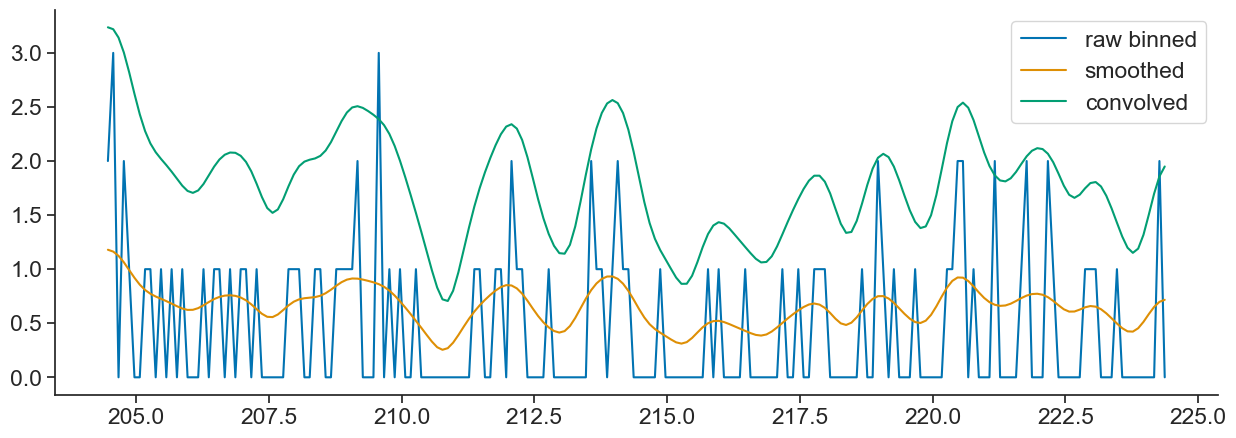

In [73]:
wake_bin = 0.1
std = 0.3
windowsize = 2

epochs = active_wake
hd_angle = hd_angle.bin_average(bin_size=wake_bin, ep=epochs)
wake_binned = hd_spikes.count(bin_size=wake_bin, ep=epochs)
wake_rate = np.sqrt(wake_binned.smooth(std=std, windowsize=windowsize))

print(wake_rate.shape)

t_a, t_b = 1000, 1200
channel = 0
kernel = gaussian(M=200, std=3)

plt.figure(figsize=(15, 5))
plt.plot(wake_binned[t_a:t_b, channel])
plt.plot(wake_rate[t_a:t_b, channel])
plt.plot(np.sqrt(wake_binned.convolve(kernel)[t_a:t_b, channel]))
plt.legend(['raw binned', 'smoothed', 'convolved'])

### UMAP

In [ ]:


reducer = umap.UMAP(n_neighbors=50,
                    min_dist=0.1,
                    n_components=2,
                    metric='euclidean',
                    )

wake_embds = reducer.fit_transform(wake_rate)
umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

<Axes: >

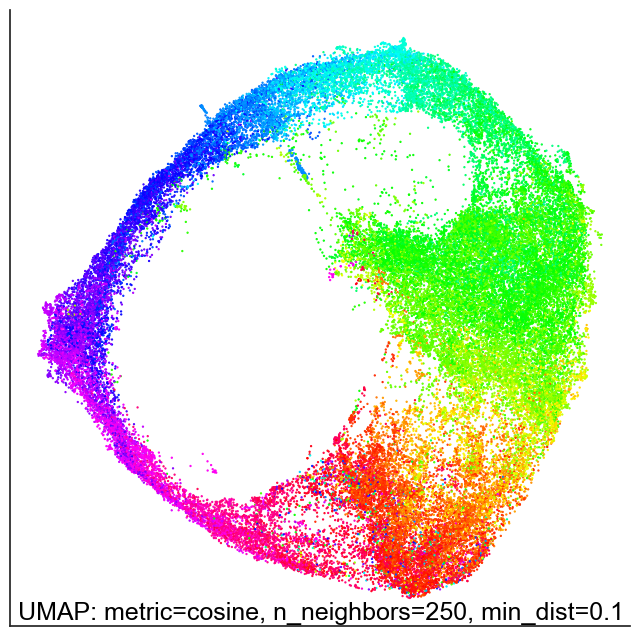

In [74]:
reducer = umap.UMAP(n_neighbors=250,
                    min_dist=0.1,
                    n_components=2,
                    metric='cosine',
                    )

wake_embds = reducer.fit_transform(wake_rate)
umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

<Axes: >

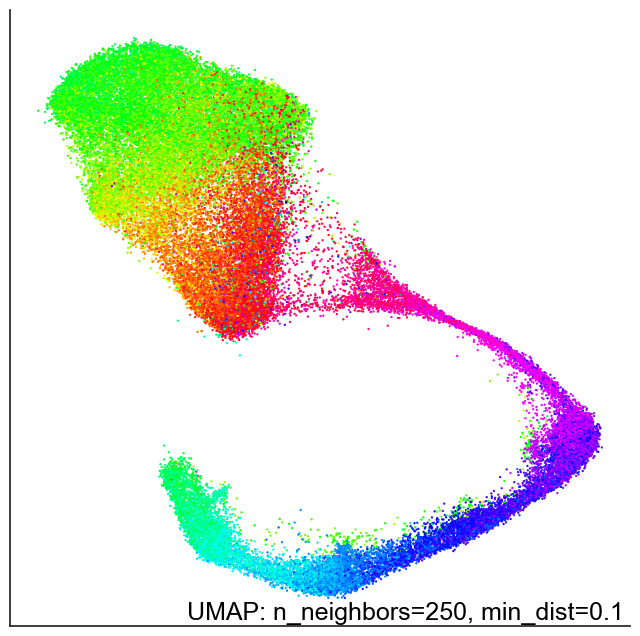

In [21]:
reducer = umap.UMAP(n_neighbors=250,
                    min_dist=0.1,
                    n_components=2,
                    metric='euclidean',
                    )

wake_embds = reducer.fit_transform(wake_rate)
umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

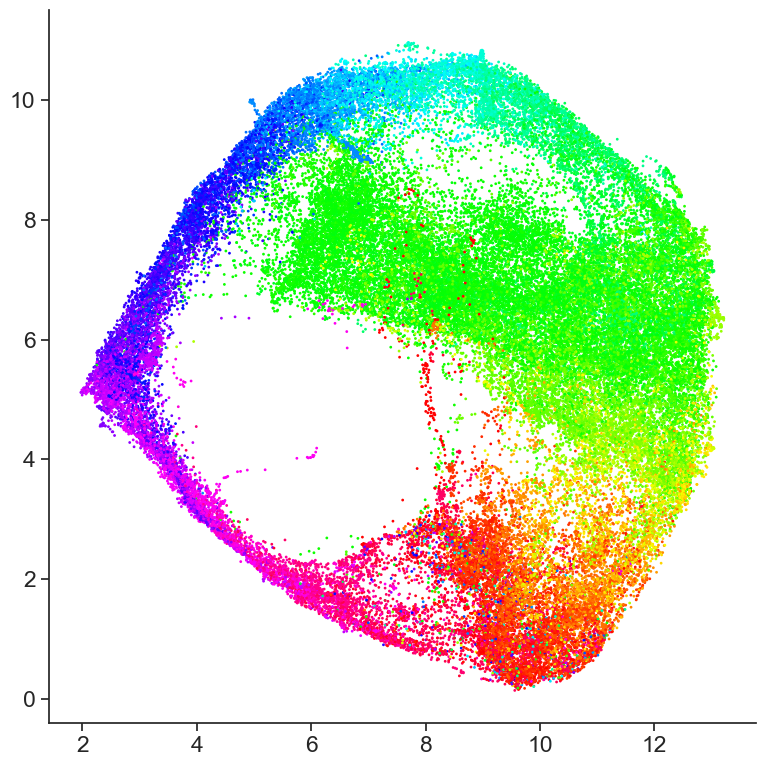

In [72]:
manifold = nap.TsdFrame(t=wake_rate.t, d= wake_embds, columns=['x', 'y'])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(manifold['x'], manifold['y'], c=hd_angle.values, cmap='hsv', s=1)
fig.tight_layout()

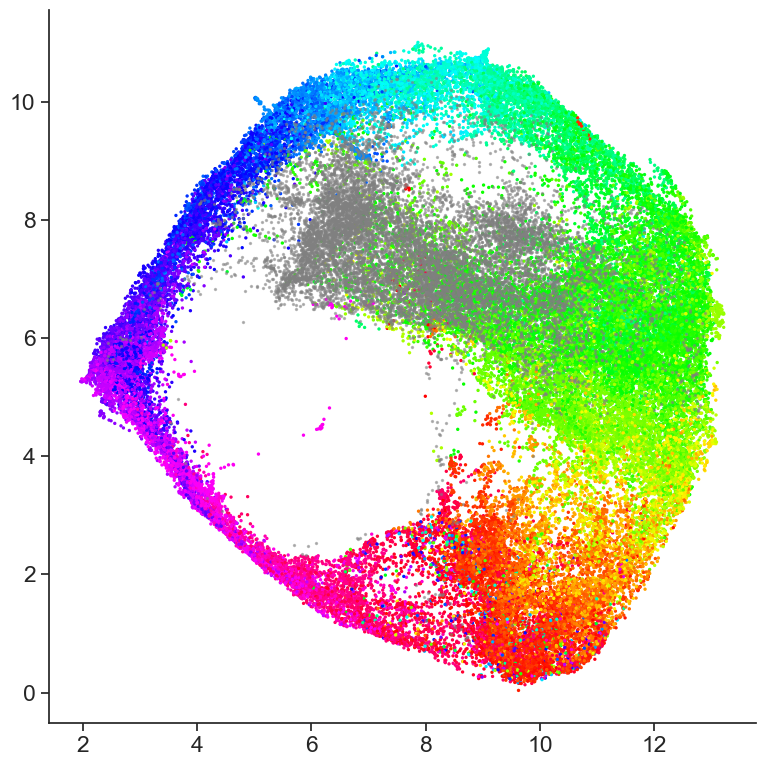

In [37]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(manifold.restrict(active_wake)['x'], manifold.restrict(active_wake)['y'], c=hd_angle.restrict(active_wake).values, cmap='hsv', s=2)
ax.scatter(manifold.restrict(sleep_states[sleep_states['state'] == 'nrem'])['x'], manifold.restrict(sleep_states[sleep_states['state'] == 'nrem'])['y'], c='gray', s=2, alpha=0.5)
fig.tight_layout()

In [38]:
hd_angle = np.deg2rad(hd_angle)
tcs = nap.compute_tuning_curves(data = hd_spikes.restrict(hd_angle.time_support),
                                features = hd_angle,
                                bins = 61,
                                epochs = hd_angle.time_support,
                                range = (0.0, 2 * np.pi),
                                feature_names=['head_direction'])

pref_ang = tcs.idxmax(dim="head_direction")

In [39]:
# Normalizes data into the range [0,1]
norm = plt.Normalize()
# Assigns a color in the HSV colormap for each value of preferred angle
color = plt.cm.hsv(norm([i / (2 * np.pi) for i in pref_ang.values]))
color = xr.DataArray(
    color, 
    dims=("unit", "color"),
    coords={"unit": pref_ang.unit}
)

In [40]:
tcs.values = gaussian_filter1d(
    tcs.values, 
    sigma=3, 
    axis=1, 
    mode="wrap" # important for circular variables!
)

In [41]:
hd_spikes.set_info({"preferred_angle": pref_ang.values})
hd_spikes

Index    rate     labels    preferred_angle
-------  -------  --------  -----------------
4        3.54915  good      3.97
5        3.55288  good      1.7
6        2.30517  good      1.8
7        1.59948  good      5.51
8        5.6952   good      5.51
9        1.57556  good      4.48
10       1.08584  good      4.27
...      ...      ...       ...
29       1.1319   good      2.42
31       0.80389  good      3.04
32       1.31589  good      3.24
33       1.06507  good      2.94
34       1.23341  good      1.08
35       1.42646  good      5.51
36       4.00446  good      0.05

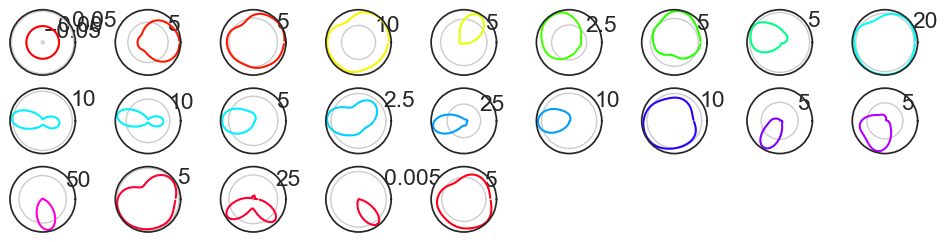

In [42]:
sorted_tuning_curves = tcs.sortby(pref_ang)
plt.figure(figsize=(12, 9))
for i, n in enumerate(sorted_tuning_curves.coords["unit"]):
    # Plot the curves in 8 rows and 4 columns
    plt.subplot(9, 9, i + 1, projection='polar')
    plt.plot(
        sorted_tuning_curves.coords["head_direction"], 
        sorted_tuning_curves.sel(unit=n).values,
        color=color.sel(unit=n).values
    )  # Colour of the curves determined by preferred angle    
    plt.xticks([])
plt.show()

In [ ]:
manifold.save(PROCESSED_DATA_PATH / unit_id / "manifold_wake_pre_ttx")
hd_spikes.save(PROCESSED_DATA_PATH / unit_id / "hd_spikes_wake_pre_ttx")
np.save(PROCESSED_DATA_PATH / unit_id / "pulses", pulses)

### Viz

In [ ]:
manifold = nap.TsdFrame(t=wake_rate.t, d=wake_embds, columns=['x', 'y'])

In [46]:
hd_spikes.save(PROCESSED_DATA_PATH / unit_id / "hd_spikes_wake_filtered")
manifold.save(PROCESSED_DATA_PATH / unit_id / "manifold_wake")

In [44]:
manifold = nap.load_file(PROCESSED_DATA_PATH / unit_id / "manifold_wake.npz")
hd_spikes = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_wake_filtered.npz")

In [45]:
# Drop units that have no spikes (which result in NaN rates)
# We check spike counts directly to avoid potential metadata desync
valid_keys = [k for k in hd_spikes.keys() if len(hd_spikes[k]) > 0]
hd_spikes = hd_spikes[valid_keys]
hd_spikes

Index    rate     labels    preferred_angle
-------  -------  --------  -----------------
4        8.85167  good      3.97
5        3.41071  good      1.7
6        4.76168  good      1.8
7        3.29032  good      5.51
8        7.33562  good      5.51
9        2.84348  good      4.48
10       1.50026  good      4.27
...      ...      ...       ...
28       15.3006  good      0.98
29       2.4458   good      2.42
31       1.46629  good      3.04
32       3.18006  good      3.24
33       1.95277  good      2.94
34       1.80556  good      1.08
35       0.00045  good      5.51

In [51]:
# turn_spikes     = nap.load_file(PROCESSED_DATA_PATH / unit_id / "turn_spikes.npz")
turn_spikes = nap.load_file(PROCESSED_DATA_PATH / unit_id / "spikes_shank_3.npz")
turn_spikes = turn_spikes.restrict(manifold.time_support)

valid_keys = [k for k in turn_spikes.keys() if len(turn_spikes[k]) > 0]
turn_spikes = turn_spikes[valid_keys]
turn_spikes

Index    rate
-------  --------
22       19.25456
23       2.33912
24       1.18945
33       12.86925
86       0.80429
88       3.75684
93       0.00313
...      ...
205      0.04425
206      2.89399
215      2.70774
216      3.13581
218      5.28123
220      0.27937
222      2.6982

In [48]:
fname = "Basler_acA1300-200um__23157472__20220429_103515923.avi"

In [49]:
nrem = sleep_states[sleep_states['state'] == 'nrem'].intersect(manifold.time_support)

In [52]:
vid = viz.VideoHandler(RAW_DATA_PATH / unit_id / fname,
                        time=pulses)

scope({'hd_units': hd_spikes, 'sc_units': turn_spikes, 'manifold': manifold, 'video': vid, 'nrem': nrem})